In [1]:
!pip install -q gdown opencv-python scikit-learn seaborn


install libaries

1.downloard data set zip from google drive

---



In [2]:
import gdown
import zipfile
import os
import shutil
from pathlib import Path

drive_url = "https://drive.google.com/file/d/1T8nuyMwO5PH-DfSkDn-D4Q_ynT9DQgWm/view?usp=sharing"

zip_path = "/content/cabbage_dataset.zip"
extract_path = "/content/cabbage_dataset_raw"

gdown.download(drive_url, zip_path, quiet=False, fuzzy=True)

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted.")
print(os.listdir(extract_path))


Downloading...
From (original): https://drive.google.com/uc?id=1T8nuyMwO5PH-DfSkDn-D4Q_ynT9DQgWm
From (redirected): https://drive.google.com/uc?id=1T8nuyMwO5PH-DfSkDn-D4Q_ynT9DQgWm&confirm=t&uuid=c3b2b342-40fc-400a-8b04-acc0817f2830
To: /content/cabbage_dataset.zip
100%|██████████| 1.77G/1.77G [00:33<00:00, 53.6MB/s]


Dataset extracted.
['cabbage']


2.Automatically Find Class Folder Directory

This helps if your ZIP contains an extra folder inside it.

In [3]:
from pathlib import Path

raw_path = Path("/content/cabbage_dataset_raw")

def find_dataset_root(path):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    candidates = []
    for folder in path.rglob("*"):
        if folder.is_dir():
            subdirs = [d for d in folder.iterdir() if d.is_dir()]
            image_count = 0

            for subdir in subdirs:
                image_count += sum(
                    1 for f in subdir.iterdir()
                    if f.is_file() and f.suffix.lower() in image_extensions
                )

            if len(subdirs) >= 2 and image_count > 0:
                candidates.append(folder)

    if not candidates:
        raise ValueError("Could not find dataset root. Check ZIP folder structure.")

    return candidates[0]

dataset_root = find_dataset_root(raw_path)

print("Detected dataset root:", dataset_root)
print("Classes:")
for class_name in sorted(os.listdir(dataset_root)):
    print("-", class_name)


Detected dataset root: /content/cabbage_dataset_raw/cabbage
Classes:
- alternaria_leaf_spot
- bacterial_spot_rot
- black_Rot
- cabbage_aphid_colony
- club_root
- downy_mildew
- healthy_cabbage
- ring_spot


5: Split Dataset Into 70% Train, 15% Validation, 15% Test

In [4]:
import random
from sklearn.model_selection import train_test_split

source_dir = Path(dataset_root)
split_dir = Path("/content/cabbage_dataset_split")

if split_dir.exists():
    shutil.rmtree(split_dir)

train_dir = split_dir / "train"
val_dir = split_dir / "val"
test_dir = split_dir / "test"

for folder in [train_dir, val_dir, test_dir]:
    folder.mkdir(parents=True, exist_ok=True)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

random.seed(42)

for class_folder in source_dir.iterdir():
    if not class_folder.is_dir():
        continue

    images = [
        file for file in class_folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    if len(images) == 0:
        continue

    train_files, temp_files = train_test_split(
        images,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    for split_name, files in [
        ("train", train_files),
        ("val", val_files),
        ("test", test_files)
    ]:
        target_class_dir = split_dir / split_name / class_folder.name
        target_class_dir.mkdir(parents=True, exist_ok=True)

        for file in files:
            shutil.copy2(file, target_class_dir / file.name)

print("Dataset split completed.")

for split_name in ["train", "val", "test"]:
    print(f"\n{split_name.upper()}")
    split_path = split_dir / split_name
    total = 0

    for class_name in sorted(os.listdir(split_path)):
        count = len(os.listdir(split_path / class_name))
        total += count
        print(class_name, ":", count)

    print("Total:", total)


Dataset split completed.

TRAIN
alternaria_leaf_spot : 140
bacterial_spot_rot : 140
black_Rot : 140
cabbage_aphid_colony : 140
club_root : 140
downy_mildew : 140
healthy_cabbage : 140
ring_spot : 140
Total: 1120

VAL
alternaria_leaf_spot : 30
bacterial_spot_rot : 30
black_Rot : 30
cabbage_aphid_colony : 30
club_root : 30
downy_mildew : 30
healthy_cabbage : 30
ring_spot : 30
Total: 240

TEST
alternaria_leaf_spot : 30
bacterial_spot_rot : 30
black_Rot : 30
cabbage_aphid_colony : 30
club_root : 30
downy_mildew : 30
healthy_cabbage : 30
ring_spot : 30
Total: 240


6: Load Dataset For Training

In [5]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)


Found 1120 files belonging to 8 classes.
Found 240 files belonging to 8 classes.
Found 240 files belonging to 8 classes.
Class names: ['alternaria_leaf_spot', 'bacterial_spot_rot', 'black_Rot', 'cabbage_aphid_colony', 'club_root', 'downy_mildew', 'healthy_cabbage', 'ring_spot']
Number of classes: 8


7: Improve Dataset Loading Performance

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


8: Build MobileNetV2 Transfer Learning Model

In [7]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 9: Train The Model

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_cabbage_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)


Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 905ms/step - accuracy: 0.1679 - loss: 2.3047 - val_accuracy: 0.2333 - val_loss: 1.9568
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 34s 961ms/step - accuracy: 0.2473 - loss: 1.9804 - val_accuracy: 0.3583 - val_loss: 1.6866
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 930ms/step - accuracy: 0.3634 - loss: 1.7314 - val_accuracy: 0.5292 - val_loss: 1.4663
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 914ms/step - accuracy: 0.4589 - loss: 1.5003 - val_accuracy: 0.6208 - val_loss: 1.2863
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 854ms/step - accuracy: 0.5232 - loss: 1.3404 - val_accuracy: 0.6792 - val_loss: 1.1440
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 877ms/step - accuracy: 0.5857 - loss: 1.2199 - val_accuracy: 0.7375 - val_loss: 1.0206
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 957ms/step - accuracy: 0.6161 - loss: 1.1386 - val_accuracy: 0.7667 - val_loss: 0.9218
Epoch 8/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 840ms/step - accuracy: 0.6821 - loss: 1.0143 - val_accu

10: Fine-Tune MobileNetV2

After initial training, unfreeze some upper layers for better accuracy.

In [9]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 940ms/step - accuracy: 0.7027 - loss: 0.9423 - val_accuracy: 0.9333 - val_loss: 0.3057
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 941ms/step - accuracy: 0.7821 - loss: 0.7090 - val_accuracy: 0.9375 - val_loss: 0.2864
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8554 - loss: 0.5665 - val_accuracy: 0.9500 - val_loss: 0.2692
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 891ms/step - accuracy: 0.8813 - loss: 0.4730 - val_accuracy: 0.9458 - val_loss: 0.2565
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 952ms/step - accuracy: 0.9009 - loss: 0.4080 - val_accuracy: 0.9417 - val_loss: 0.2432
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 915ms/step - accuracy: 0.9152 - loss: 0.3483 - val_accuracy: 0.9417 - val_loss: 0.2273
Epoch 7/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 946ms/step - accuracy: 0.9411 - loss: 0.2989 - val_accuracy: 0.9417 - val_loss: 0.2079
Epoch 8/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 937ms/step - accuracy: 0.9482 - loss: 0.2720 - val_accurac

 11: Test Accuracy



In [10]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 728ms/step - accuracy: 0.9458 - loss: 0.1791
Test Loss: 0.17906694114208221
Test Accuracy: 0.9458333253860474


12: Plot Training Graphs

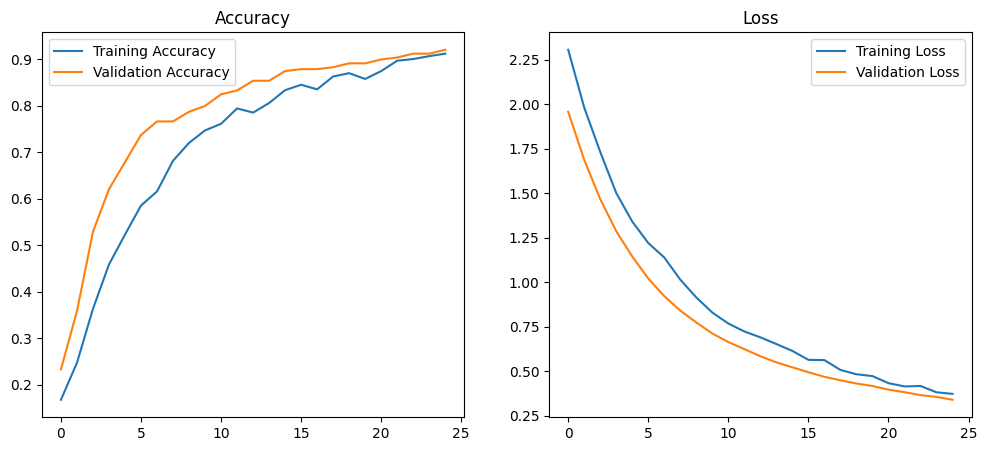

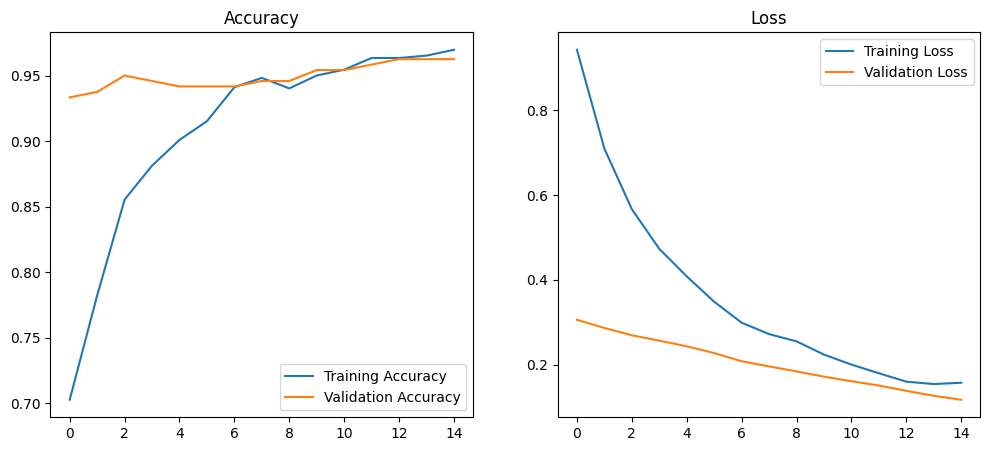

In [11]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Training Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_history(history)
plot_history(fine_tune_history)


 13: Confusion Matrix



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


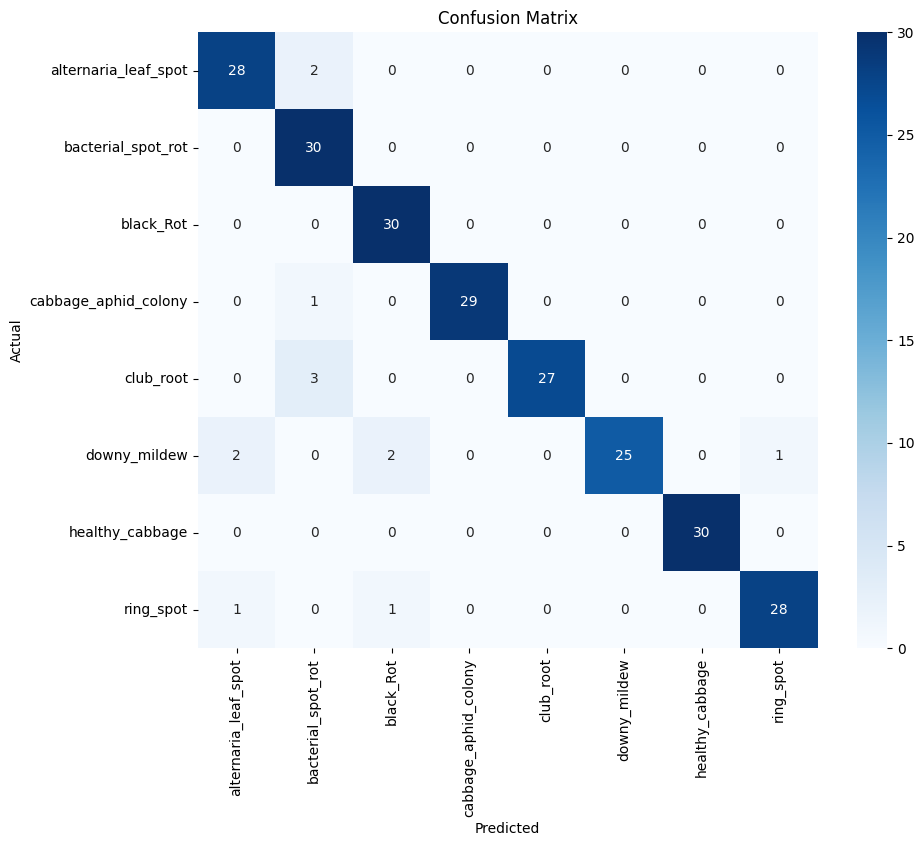

                      precision    recall  f1-score   support

alternaria_leaf_spot       0.90      0.93      0.92        30
  bacterial_spot_rot       0.83      1.00      0.91        30
           black_Rot       0.91      1.00      0.95        30
cabbage_aphid_colony       1.00      0.97      0.98        30
           club_root       1.00      0.90      0.95        30
        downy_mildew       1.00      0.83      0.91        30
     healthy_cabbage       1.00      1.00      1.00        30
           ring_spot       0.97      0.93      0.95        30

            accuracy                           0.95       240
           macro avg       0.95      0.95      0.95       240
        weighted avg       0.95      0.95      0.95       240



In [12]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


 14: Save Model And Class Names

In [13]:
import json

model.save("/content/cabbage_disease_mobilenetv2.keras")

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model saved at /content/cabbage_disease_mobilenetv2.keras")
print("Class names saved at /content/class_names.json")


Model saved at /content/cabbage_disease_mobilenetv2.keras
Class names saved at /content/class_names.json



15: Download Model Files



In [14]:
from google.colab import files

files.download("/content/cabbage_disease_mobilenetv2.keras")
files.download("/content/class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

16: Test Single Image Prediction In Colab



In [ ]:
from google.colab import files
from PIL import Image
import numpy as np

uploaded = files.upload()

for filename in uploaded.keys():
    image_path = filename

    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    confidence = float(np.max(prediction)) * 100

    print("Image:", filename)
    print("Predicted Disease:", class_names[predicted_index])
    print("Confidence:", round(confidence, 2), "%")


17: OpenCV Severity Estimation

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_severity(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError("Image not found or invalid image path.")

    image = cv2.resize(image, (224, 224))
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Green leaf mask
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    leaf_mask = cv2.inRange(hsv, lower_green, upper_green)

    # Brown/yellow/dark infected regions
    lower_infected_1 = np.array([5, 40, 40])
    upper_infected_1 = np.array([35, 255, 255])

    lower_infected_2 = np.array([0, 0, 0])
    upper_infected_2 = np.array([180, 255, 80])

    infected_mask_1 = cv2.inRange(hsv, lower_infected_1, upper_infected_1)
    infected_mask_2 = cv2.inRange(hsv, lower_infected_2, upper_infected_2)

    infected_mask = cv2.bitwise_or(infected_mask_1, infected_mask_2)

    leaf_area = cv2.countNonZero(cv2.bitwise_or(leaf_mask, infected_mask))
    infected_area = cv2.countNonZero(infected_mask)

    if leaf_area == 0:
        return 0

    severity = (infected_area / leaf_area) * 100
    return round(severity, 2)

severity = estimate_severity(image_path)
print("Estimated Severity:", severity, "%")


In [ ]:
import os

os.listdir("/content")